# Notebook 5: External Input Protocols

This notebook demonstrates the external input system end-to-end. External inputs model experimental protocols (microfluidic ligand pulses, optogenetic stimulation, etc.) as **pseudo-species** whose dynamics are prescribed by a `PulseSchedule` rather than CRN kinetics.

**Key design invariant:** the same CRN with different input protocols produces the same `CRNContext` from the encoder — the protocol is experiment-level, not network-level.

Contents:
1. Pulse Schedule Visualization
2. Birth-Death with External Input
3. Toggle Switch with External Input
4. Negative Autoregulation with External Perturbation
5. Random Protocol for Training

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from crn_surrogate.crn import (
    CRN,
    Reaction,
    InputProtocol,
    PulseSchedule,
    PulseEvent,
    EMPTY_PROTOCOL,
    constant_input,
    single_pulse,
    repeated_pulse,
    step_sequence,
    random_protocol,
    random_input_protocol,
)
from crn_surrogate.crn.propensities import mass_action, hill_repression, constant_rate
from crn_surrogate.simulation import GillespieSSA

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

ssa = GillespieSSA()

## 1. Pulse Schedule Visualization

Four factory functions build `PulseSchedule` objects from common experimental patterns. Each schedule is evaluated over a dense time grid using `evaluate_array`.

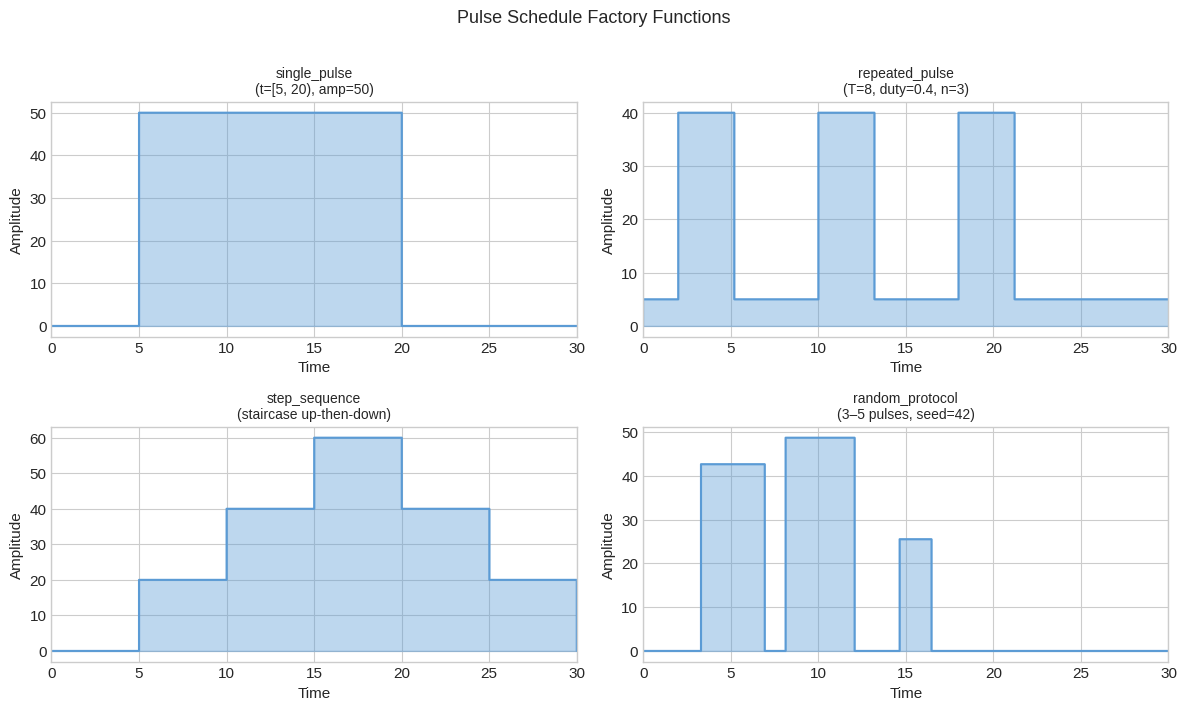

In [2]:
t_max_demo = 30.0
t_grid = np.linspace(0.0, t_max_demo, 3000)

schedules = [
    (
        single_pulse(t_start=5.0, t_end=20.0, amplitude=50.0, baseline=0.0),
        'single_pulse\n(t=[5, 20), amp=50)',
    ),
    (
        repeated_pulse(period=8.0, duty_cycle=0.4, amplitude=40.0, n_pulses=3, t_start=2.0, baseline=5.0),
        'repeated_pulse\n(T=8, duty=0.4, n=3)',
    ),
    (
        step_sequence(
            times=[0.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0],
            amplitudes=[0.0, 20.0, 40.0, 60.0, 40.0, 20.0],
            baseline=0.0,
        ),
        'step_sequence\n(staircase up-then-down)',
    ),
    (
        random_protocol(t_max=t_max_demo, n_pulses_range=(3, 5), duration_range=(1.5, 4.0),
                        amplitude_range=(10.0, 80.0), gap_range=(1.0, 3.0), rng=np.random.default_rng(42)),
        'random_protocol\n(3–5 pulses, seed=42)',
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

fill_color = '#5B9BD5'
for ax, (sched, title) in zip(axes, schedules):
    vals = sched.evaluate_array(t_grid)
    ax.fill_between(t_grid, vals, step='post', alpha=0.4, color=fill_color)
    ax.step(t_grid, vals, where='post', color=fill_color, linewidth=1.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Time')
    ax.set_ylabel('Amplitude')
    ax.set_xlim(0, t_max_demo)

fig.suptitle('Pulse Schedule Factory Functions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 2. Birth-Death with External Input

We construct a modified birth-death process where the birth rate is driven by an external "inducer" species $I$:

$$\text{Birth: } \emptyset \xrightarrow{k \cdot I} A \qquad \text{Death: } A \xrightarrow{k_{\deg}} \emptyset$$

The inducer $I$ is an external pseudo-species — it appears in the dependency graph and modulates the birth propensity, but its own dynamics are prescribed by an `InputProtocol`. Its net stoichiometric change in every reaction is zero.

**Species layout:** index 0 = $A$ (internal), index 1 = $I$ (external inducer).

In [3]:
# Stoichiometry vectors: [A, I]
# Birth: A += 1, I unchanged  →  [+1, 0]
# Death: A -= 1, I unchanged  →  [-1, 0]

k_birth = 0.5   # effective birth rate per unit inducer
k_deg   = 0.3   # degradation rate
n_species_bd = 2

# Birth propensity: k_birth * I  (mass action on inducer alone)
birth_propensity = mass_action(
    rate_constant=k_birth,
    reactant_stoichiometry=torch.tensor([0.0, 1.0]),  # depends on I only
)
# Death propensity: k_deg * A
death_propensity = mass_action(
    rate_constant=k_deg,
    reactant_stoichiometry=torch.tensor([1.0, 0.0]),  # depends on A only
)

crn_bd_ext = CRN(
    reactions=[
        Reaction(stoichiometry=torch.tensor([1.0, 0.0]), propensity=birth_propensity),
        Reaction(stoichiometry=torch.tensor([-1.0, 0.0]), propensity=death_propensity),
    ],
    species_names=['A', 'I'],
    external_species=frozenset({1}),  # I is external
)
print(crn_bd_ext)
print(f"External species: {crn_bd_ext.external_species}")
print(f"is_external array: {crn_bd_ext.is_external}")

CRN(n_species=2, n_reactions=2, species=('A', 'I'))
External species: frozenset({1})
is_external array: [False  True]


In [4]:
# Input protocol: three pulses of increasing amplitude
inducer_schedule = PulseSchedule(
    events=(
        PulseEvent(t_start=5.0,  t_end=15.0, amplitude=20.0),
        PulseEvent(t_start=20.0, t_end=30.0, amplitude=50.0),
        PulseEvent(t_start=35.0, t_end=45.0, amplitude=30.0),
    ),
    baseline=2.0,
)
protocol_bd = InputProtocol(schedules={1: inducer_schedule})

t_max_bd = 50.0
x0_bd = torch.tensor([0.0, 0.0])  # initial state; I will be set by protocol at t=0

M = 20
trajs_bd = [
    ssa.simulate(
        stoichiometry=crn_bd_ext.stoichiometry_matrix,
        propensity_fn=crn_bd_ext.evaluate_propensities,
        initial_state=x0_bd.clone(),
        t_max=t_max_bd,
        input_protocol=protocol_bd,
        external_species=crn_bd_ext.external_species,
    )
    for _ in range(M)
]

t_plot = np.linspace(0.0, t_max_bd, 500)
inducer_vals = inducer_schedule.evaluate_array(t_plot)

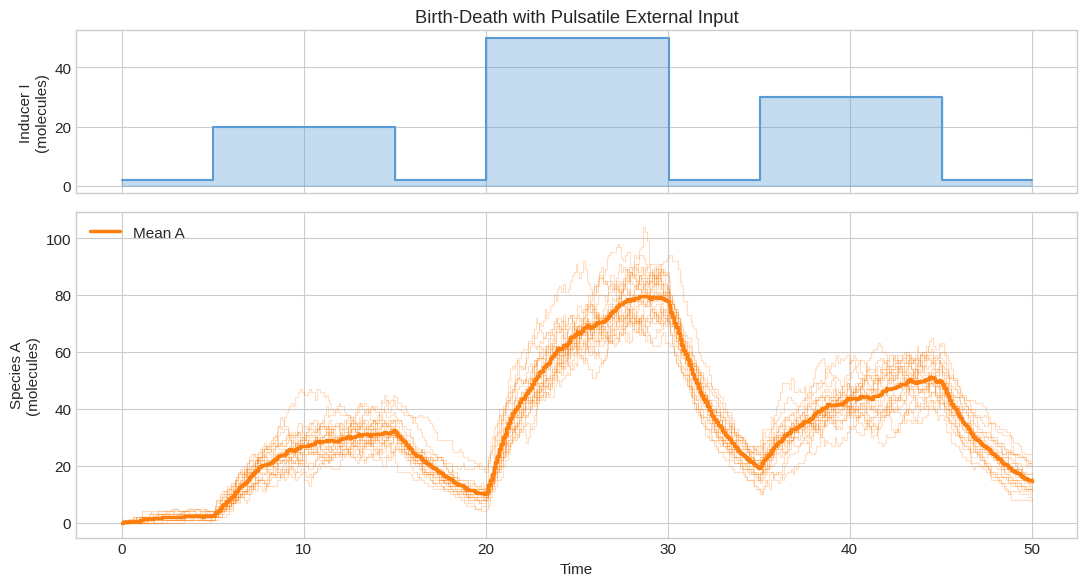

The protein A tracks the inducer pulses: higher inducer → higher mean A.
Expected E[A] per pulse amplitude: 33.3, 83.3, 50.0


In [5]:
from crn_surrogate.simulation import interpolate_to_grid

fig, (ax_in, ax_out) = plt.subplots(
    2, 1, figsize=(11, 6), sharex=True,
    gridspec_kw={'height_ratios': [1, 2]},
)

# Top: inducer protocol
ax_in.fill_between(t_plot, inducer_vals, step='post', alpha=0.35, color='#5B9BD5')
ax_in.step(t_plot, inducer_vals, where='post', color='#5B9BD5', linewidth=1.5)
ax_in.set_ylabel('Inducer I\n(molecules)')
ax_in.set_title('Birth-Death with Pulsatile External Input')

# Bottom: SSA trajectories for A
grid_states = np.stack([
    interpolate_to_grid(traj.times, traj.states, torch.tensor(t_plot))[:, 0].numpy()
    for traj in trajs_bd
], axis=0)  # (M, T)

for i in range(M):
    ax_out.step(t_plot, grid_states[i], where='post',
                color='tab:orange', alpha=0.25, linewidth=0.8)
ax_out.step(t_plot, grid_states.mean(axis=0), where='post',
            color='tab:orange', linewidth=2.5, label='Mean A')

ax_out.set_xlabel('Time')
ax_out.set_ylabel('Species A\n(molecules)')
ax_out.legend(loc='upper left')

plt.tight_layout()
plt.show()

print("The protein A tracks the inducer pulses: higher inducer → higher mean A.")
print(f"Expected E[A] per pulse amplitude: {20*k_birth/k_deg:.1f}, {50*k_birth/k_deg:.1f}, {30*k_birth/k_deg:.1f}")

## 3. Toggle Switch with External Input

A bistable toggle switch has two mutually repressing genes. We add an external signal $S$ that **activates** gene $A$'s production, biasing the switch.

**Species layout:** index 0 = $A$, index 1 = $B$, index 2 = $S$ (external).

**Reactions:**
- Production of $A$: Hill repression by $B$, boosted by external $S$ via a constant-rate baseline
- Degradation of $A$: mass action
- Production of $B$: Hill repression by $A$
- Degradation of $B$: mass action

To model the boost from $S$, we add an extra production reaction for $A$ that has propensity $k_{boost} \cdot S$ (mass action on $S$). When $S$ is high, $A$ is strongly produced and dominates; when $S$ is low, the switch may flip to the $B$-high state.

In [15]:
# Parameters
k_max   = 50.0   # max production rate
k_half  = 30.0   # repression half-point
n_hill  = 3.0    # Hill coefficient
k_deg   = 0.2    # degradation rate
k_boost = 0.8    # boost per unit external signal

# Reactions: stoichiometry [A, B, S]
# Prod A (basal, repressed by B):  [+1, 0, 0, 0]
# Boost A (from signal S1):        [+1, 0, 0, 0]  — depends on S1
# Deg A:                           [-1, 0, 0, 0]
# Prod B (repressed by A):         [0, +1, 0, 0]
# Boost B (from signal S2):        [0, +1, 0, 0]  — depends on S2
# Deg B:                           [0, -1, 0, 0]

crn_toggle = CRN(
    reactions=[
        Reaction(
            stoichiometry=torch.tensor([1.0, 0.0, 0.0, 0.0]),
            propensity=hill_repression(
                k_max=k_max, k_half=k_half, hill_coefficient=n_hill, species_index=1,
            ),
        ),
        Reaction(
            stoichiometry=torch.tensor([1.0, 0.0, 0.0, 0.0]),
            propensity=mass_action(
                rate_constant=k_boost,
                reactant_stoichiometry=torch.tensor([0.0, 0.0, 1.0, 0.0]),  # depends on S1
            ),
        ),
        Reaction(
            stoichiometry=torch.tensor([-1.0, 0.0, 0.0, 0.0]),
            propensity=mass_action(
                rate_constant=k_deg,
                reactant_stoichiometry=torch.tensor([1.0, 0.0, 0.0, 0.0]),
            ),
        ),
        Reaction(
            stoichiometry=torch.tensor([0.0, 1.0, 0.0, 0.0]),
            propensity=hill_repression(
                k_max=k_max, k_half=k_half, hill_coefficient=n_hill, species_index=0,
            ),
        ),
        Reaction(
            stoichiometry=torch.tensor([0.0, 1.0, 0.0, 0.0]),
            propensity=mass_action(
                rate_constant=k_boost,
                reactant_stoichiometry=torch.tensor([0.0, 0.0, 0.0, 1.0]),  # depends on S2
            ),
        ),
        Reaction(
            stoichiometry=torch.tensor([0.0, -1.0, 0.0, 0.0]),
            propensity=mass_action(
                rate_constant=k_deg,
                reactant_stoichiometry=torch.tensor([0.0, 1.0, 0.0, 0.0]),
            ),
        ),
    ],
    species_names=['A', 'B', 'S1', 'S2'],
    external_species=frozenset({2, 3}),  # S is external
)
print(crn_toggle)
print(f"External species: {crn_toggle.external_species}")

CRN(n_species=4, n_reactions=6, species=('A', 'B', 'S1', 'S2'))
External species: frozenset({2, 3})


In [16]:
# Periodic pulses: high signal for 30 time units, then off for 30 time units
# When S is high, A dominates; when S is off, B may take over
t_max_toggle = 240.0

signal_schedule_2 = repeated_pulse(
    period=120.0,
    duty_cycle=0.25,
    amplitude=20.0,
    n_pulses=2,
    t_start=70.0,
    baseline=0.0,
)
signal_schedule_3 = repeated_pulse(
    period=120.0,
    duty_cycle=0.25,
    amplitude=20.0,
    n_pulses=2,
    t_start=10.0,
    baseline=0.0,
)
protocol_toggle = InputProtocol(schedules={2: signal_schedule_2, 3: signal_schedule_3})

x0_toggle = torch.tensor([0.0, 0.0, 0.0, 0.0])

trajs_toggle = [
    ssa.simulate(
        stoichiometry=crn_toggle.stoichiometry_matrix,
        propensity_fn=crn_toggle.evaluate_propensities,
        initial_state=x0_toggle.clone(),
        t_max=t_max_toggle,
        max_reactions=500_000,
        input_protocol=protocol_toggle,
        external_species=crn_toggle.external_species,
    )
    for _ in range(M)
]
print(f"Simulated {M} trajectories.")

Simulated 20 trajectories.


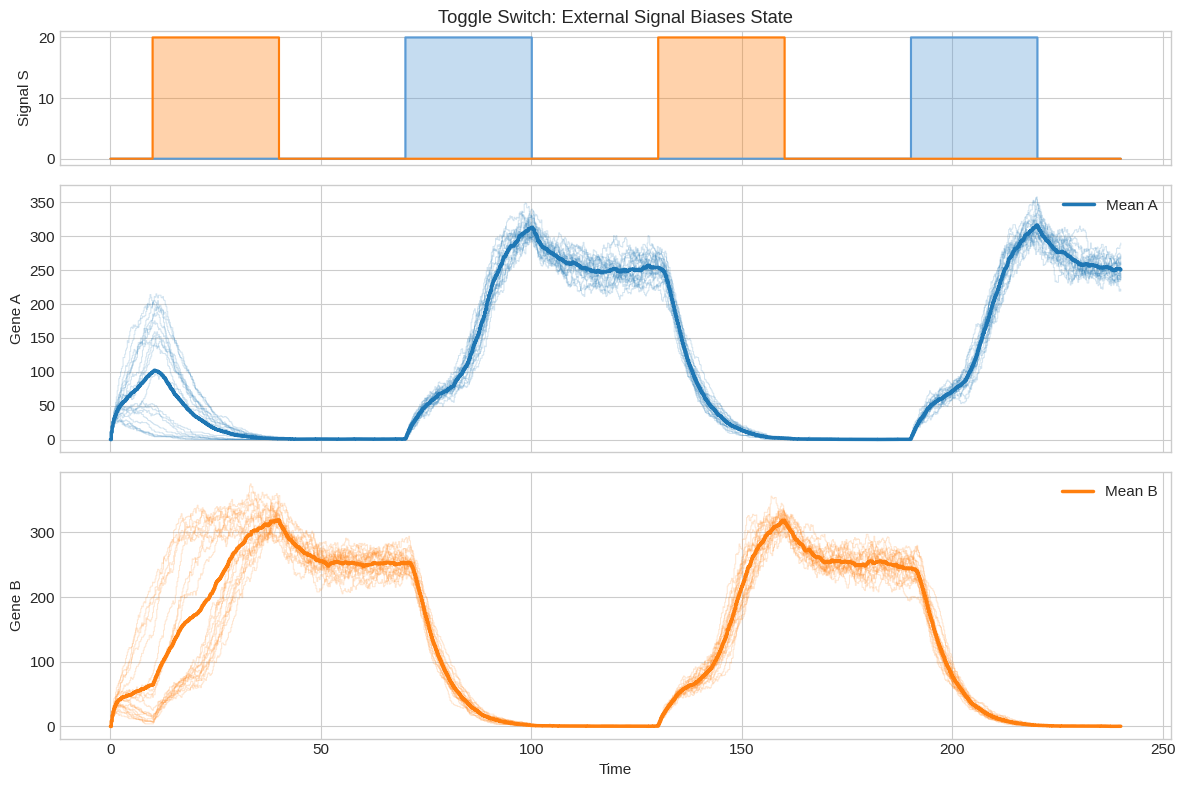

In [18]:
t_plot_toggle = np.linspace(0.0, t_max_toggle, 1200)
signal_vals_2 = signal_schedule_2.evaluate_array(t_plot_toggle)
signal_vals_3 = signal_schedule_3.evaluate_array(t_plot_toggle)

grid_toggle = np.stack([
    interpolate_to_grid(traj.times, traj.states, torch.tensor(t_plot_toggle)).numpy()
    for traj in trajs_toggle
], axis=0)  # (M, T, 3)

fig, (ax_in, ax_A, ax_B) = plt.subplots(
    3, 1, figsize=(12, 8), sharex=True,
    gridspec_kw={'height_ratios': [1, 2, 2]},
)

# Signal
ax_in.fill_between(t_plot_toggle, signal_vals_2, step='post', alpha=0.35, color='#5B9BD5')
ax_in.step(t_plot_toggle, signal_vals_2, where='post', color='#5B9BD5', linewidth=1.5)
ax_in.fill_between(t_plot_toggle, signal_vals_3, step='post', alpha=0.35, color='tab:orange')
ax_in.step(t_plot_toggle, signal_vals_3, where='post', color='tab:orange', linewidth=1.5)
ax_in.set_ylabel('Signal S')
ax_in.set_title('Toggle Switch: External Signal Biases State')

# Gene A
for i in range(M):
    ax_A.step(t_plot_toggle, grid_toggle[i, :, 0], where='post',
              color='tab:blue', alpha=0.2, linewidth=0.7)
ax_A.step(t_plot_toggle, grid_toggle[:, :, 0].mean(axis=0), where='post',
          color='tab:blue', linewidth=2.5, label='Mean A')
ax_A.set_ylabel('Gene A')
ax_A.legend(loc='upper right')

# Gene B
for i in range(M):
    ax_B.step(t_plot_toggle, grid_toggle[i, :, 1], where='post',
              color='tab:orange', alpha=0.2, linewidth=0.7)
ax_B.step(t_plot_toggle, grid_toggle[:, :, 1].mean(axis=0), where='post',
          color='tab:orange', linewidth=2.5, label='Mean B')
ax_B.set_ylabel('Gene B')
ax_B.set_xlabel('Time')
ax_B.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 4. Negative Autoregulation with External Perturbation

Negative autoregulation (NAR) is a noise-suppression motif: a gene $A$ represses its own transcription, pulling the mean to a well-defined set point and reducing variance.

We add an external input $E$ that contributes a **basal production term** alongside the autoregulated production.

**Species layout:** index 0 = $A$ (internal), index 1 = $E$ (external).

**Reactions:**
- Autoregulated production: Hill repression by $A$ itself — propensity $\frac{k_{max}}{1 + (A/k_{half})^n}$
- External boost: mass action on $E$ — propensity $k_{ext} \cdot E$
- Degradation: mass action — propensity $k_{deg} \cdot A$

A staircase input shows dose-response: higher $E$ shifts the steady state up, but the NAR feedback maintains noise suppression at each step.

In [9]:
k_max_nar  = 30.0
k_half_nar = 20.0
n_nar      = 2.0
k_ext_nar  = 0.5
k_deg_nar  = 0.3

# Stoichiometry vectors: [A, E]
crn_nar = CRN(
    reactions=[
        Reaction(
            stoichiometry=torch.tensor([1.0, 0.0]),
            propensity=hill_repression(
                k_max=k_max_nar, k_half=k_half_nar, hill_coefficient=n_nar, species_index=0,
            ),
        ),
        Reaction(
            stoichiometry=torch.tensor([1.0, 0.0]),
            propensity=mass_action(
                rate_constant=k_ext_nar,
                reactant_stoichiometry=torch.tensor([0.0, 1.0]),  # depends on E
            ),
        ),
        Reaction(
            stoichiometry=torch.tensor([-1.0, 0.0]),
            propensity=mass_action(
                rate_constant=k_deg_nar,
                reactant_stoichiometry=torch.tensor([1.0, 0.0]),
            ),
        ),
    ],
    species_names=['A', 'E'],
    external_species=frozenset({1}),
)
print(crn_nar)

CRN(n_species=2, n_reactions=3, species=('A', 'E'))


In [10]:
# Staircase: 5 steps of increasing amplitude, each lasting 40 time units
t_max_nar = 200.0
step_times = [0.0, 40.0, 80.0, 120.0, 160.0, 200.0]
step_amps  = [0.0, 10.0, 20.0, 40.0, 60.0]

ext_schedule_nar = step_sequence(times=step_times, amplitudes=step_amps, baseline=0.0)
protocol_nar = InputProtocol(schedules={1: ext_schedule_nar})

x0_nar = torch.tensor([0.0, 0.0])

trajs_nar = [
    ssa.simulate(
        stoichiometry=crn_nar.stoichiometry_matrix,
        propensity_fn=crn_nar.evaluate_propensities,
        initial_state=x0_nar.clone(),
        t_max=t_max_nar,
        input_protocol=protocol_nar,
        external_species=crn_nar.external_species,
    )
    for _ in range(M)
]
print(f"Simulated {M} trajectories.")

Simulated 20 trajectories.


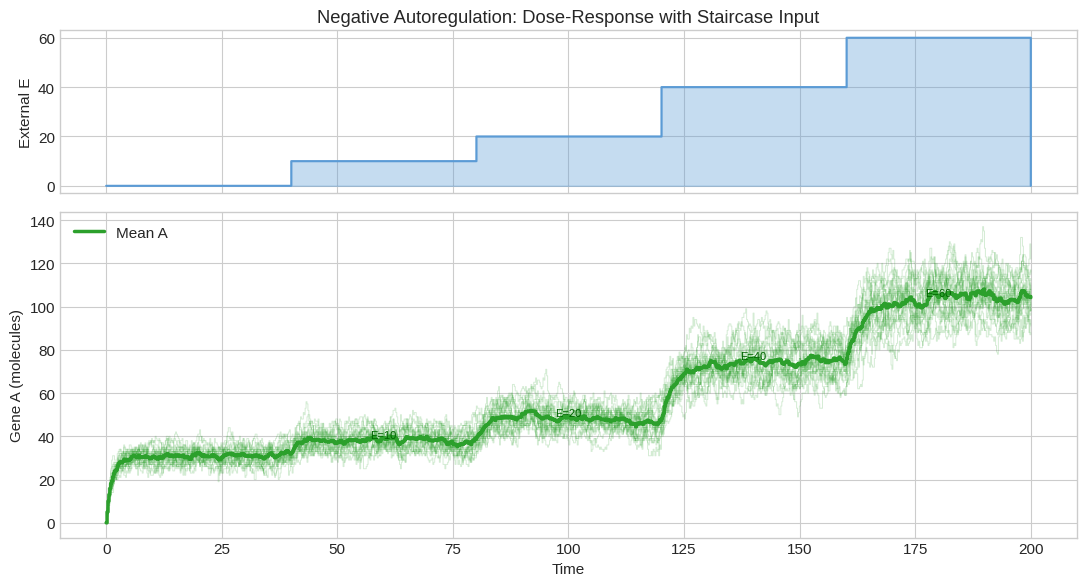

Negative feedback keeps variance low at each plateau.
Higher external input E shifts the steady state upward (dose-response).


In [11]:
t_plot_nar = np.linspace(0.0, t_max_nar, 1000)
ext_vals_nar = ext_schedule_nar.evaluate_array(t_plot_nar)

grid_nar = np.stack([
    interpolate_to_grid(traj.times, traj.states, torch.tensor(t_plot_nar))[:, 0].numpy()
    for traj in trajs_nar
], axis=0)  # (M, T)

fig, (ax_in, ax_out) = plt.subplots(
    2, 1, figsize=(11, 6), sharex=True,
    gridspec_kw={'height_ratios': [1, 2]},
)

ax_in.fill_between(t_plot_nar, ext_vals_nar, step='post', alpha=0.35, color='#5B9BD5')
ax_in.step(t_plot_nar, ext_vals_nar, where='post', color='#5B9BD5', linewidth=1.5)
ax_in.set_ylabel('External E')
ax_in.set_title('Negative Autoregulation: Dose-Response with Staircase Input')

for i in range(M):
    ax_out.step(t_plot_nar, grid_nar[i], where='post',
                color='tab:green', alpha=0.2, linewidth=0.7)
ax_out.step(t_plot_nar, grid_nar.mean(axis=0), where='post',
            color='tab:green', linewidth=2.5, label='Mean A')

# Overlay the expected steady states at each step
for i, (amp, t_s, t_e) in enumerate(zip(step_amps, step_times[:-1], step_times[1:])):
    if amp == 0.0:
        continue
    t_mid = 0.5 * (t_s + t_e)
    ax_out.annotate(
        f'E={amp:.0f}',
        xy=(t_mid, grid_nar[:, int(t_mid / t_max_nar * 1000)].mean()),
        fontsize=8, ha='center', color='darkgreen',
    )

ax_out.set_xlabel('Time')
ax_out.set_ylabel('Gene A (molecules)')
ax_out.legend(loc='upper left')

plt.tight_layout()
plt.show()

print("Negative feedback keeps variance low at each plateau.")
print("Higher external input E shifts the steady state upward (dose-response).")

## 5. Random Protocol for Training

`random_input_protocol` generates diverse `InputProtocol` objects for training data diversity. Each call with a different random seed produces an independent pulse train for each input species.

Below we generate 6 random single-species protocols and display them in a 2×3 grid, as they would look in a training batch.

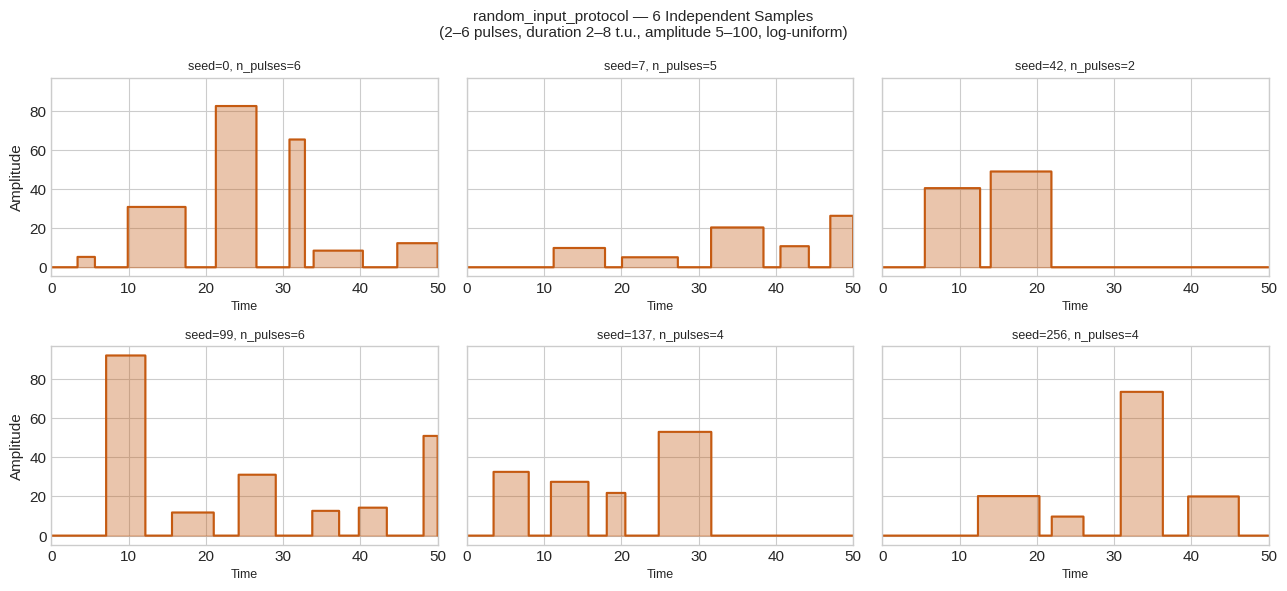


Training data generation:
  - For each (CRN, params) sample, draw a fresh random_input_protocol.
  - Simulate M SSA trajectories under that protocol.
  - The CRNTensorRepr encodes network structure + external connectivity.
  - The InputProtocol is passed to the Gillespie simulator only.
  - At inference time, any new protocol can be applied to the same encoder output.



In [12]:
t_max_rand = 50.0
t_grid_rand = np.linspace(0.0, t_max_rand, 2000)

n_show = 6
rng_seeds = [0, 7, 42, 99, 137, 256]

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharey=True)
axes = axes.flatten()

for ax, seed in zip(axes, rng_seeds):
    protocol = random_input_protocol(
        input_species_indices=[0],
        t_max=t_max_rand,
        n_pulses_range=(2, 6),
        duration_range=(2.0, 8.0),
        amplitude_range=(5.0, 100.0),
        gap_range=(1.0, 5.0),
        baseline=0.0,
        rng=np.random.default_rng(seed),
    )
    sched = protocol.schedules[0]
    vals = sched.evaluate_array(t_grid_rand)
    n_pulses = len(sched.events)

    ax.fill_between(t_grid_rand, vals, step='post', alpha=0.35, color='#C55A11')
    ax.step(t_grid_rand, vals, where='post', color='#C55A11', linewidth=1.5)
    ax.set_title(f'seed={seed}, n_pulses={n_pulses}', fontsize=9)
    ax.set_xlabel('Time', fontsize=9)
    ax.set_xlim(0, t_max_rand)

axes[0].set_ylabel('Amplitude')
axes[3].set_ylabel('Amplitude')

fig.suptitle(
    'random_input_protocol — 6 Independent Samples\n'
    '(2–6 pulses, duration 2–8 t.u., amplitude 5–100, log-uniform)',
    fontsize=11,
)
plt.tight_layout()
plt.show()

print("""
Training data generation:
  - For each (CRN, params) sample, draw a fresh random_input_protocol.
  - Simulate M SSA trajectories under that protocol.
  - The CRNTensorRepr encodes network structure + external connectivity.
  - The InputProtocol is passed to the Gillespie simulator only.
  - At inference time, any new protocol can be applied to the same encoder output.
""")

## Summary

| Feature | API |
|---|---|
| Define a pulse train | `single_pulse`, `repeated_pulse`, `step_sequence`, `random_protocol` |
| Bundle schedules for multiple species | `InputProtocol(schedules={idx: schedule, ...})` |
| Mark a species as external in the CRN | `CRN(..., external_species=frozenset({idx}))` |
| Simulate with input | `ssa.simulate(..., input_protocol=protocol, external_species=crn.external_species)` |
| Encoder boundary | `CRNTensorRepr.is_external` — external species get no reaction-to-species messages |

The input protocol never enters `crn_to_tensor_repr`. The encoder sees only network structure; the protocol is consumed only by the simulator.